# Updating dataframes

In [1]:
import numpy as np
import pandas as pd
import random  # Used for randomly sampling integers

# Set the seed
random.seed(42)

# Import data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

## Add/update Column

Using 'dictionary-like' syntax

In [3]:
penguins['body_mass_kg'] = penguins['body_mass_g'] / 1000
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45


`.assign()`: useful for method chaining

<Axes: xlabel='bill_length_cm', ylabel='body_mass_g'>

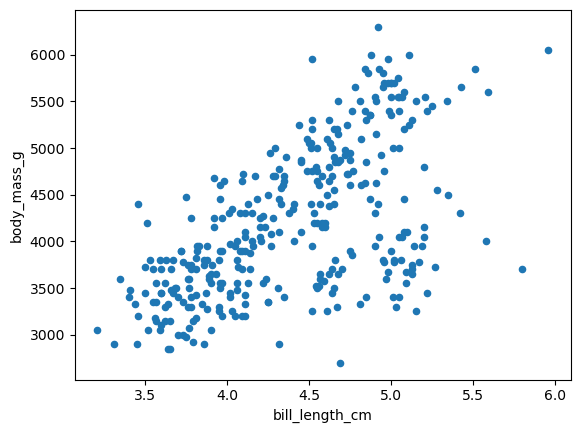

In [4]:
(penguins.assign(bill_length_cm=penguins.bill_length_mm/10)
        .plot(kind='scatter',
              x='bill_length_cm', 
              y='body_mass_g')
    )

`.insert()`: Insert new column at specified position

In [5]:
# Create random 3-digit codes for new column
codes = random.sample(range(100,1000), len(penguins))  # Sampling w/o replacement

# Insert codes at the front of data frame
penguins.insert(loc=0,  # Index
                column='id_code',
                value=codes)
        
penguins.head()

,id_code,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg
0,754,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75
1,214,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80
2,125,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25
3,859,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN
4,381,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45


## Adding Multiple Columns

`.assign()`

In [6]:
# Create columns with observer codes and flipper length in cm
penguins = penguins.assign(flipper_length_cm=penguins.flipper_length_mm/10, 
                           observer=random.choices(['A','B','C'],  # Sample with replacement
                                                    k=len(penguins))
                          )
# Examine result
penguins.head()

,id_code,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg,flipper_length_cm,observer
0,754,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75,18.1,C
1,214,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80,18.6,A
2,125,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25,19.5,C
3,859,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN,NaN,A
4,381,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45,19.3,B


## Removing Column

`.drop()`

In [7]:
# Remove duplicate length and mass measurements
penguins = penguins.drop(columns=['flipper_length_mm','body_mass_g'])

# Confirm result
print(penguins.columns)

Index(['id_code', 'species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'sex', 'year', 'body_mass_kg', 'flipper_length_cm', 'observer'],
      dtype='object')
